In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from bertopic import BERTopic
from bertopic.backend import BaseEmbedder
from bertopic.cluster import BaseCluster
from bertopic.dimensionality import BaseDimensionalityReduction
from bertopic.vectorizers import ClassTfidfTransformer

c:\Users\sebas\Documents\VS_Studio_code\modelo_computacional\Modelo_computacional\entorno_virtual\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_clusters = pd.read_pickle("documentos_udea_2004_2024_preprocesados.pkl")

print("Shape:", df_clusters.shape)
print("Tipo de resuelve_tokens:", type(df_clusters["resuelve_tokens"].iloc[0]))
print(df_clusters["resuelve_tokens"].head(3).to_list())

Shape: (23518, 8)
Tipo de resuelve_tokens: <class 'list'>
[['modificar', 'prestacion', 'servicios', 'salud', 'sistema', 'seguridad', 'social'], ['aprobar', 'presupuesto', 'fondos', 'generales', 'vigencia', 'fiscal'], ['aprobar', 'presupuesto', 'fondos', 'seguridad', 'social', 'vigencia', 'fiscal']]


In [3]:
df_clusters["resuelve_doc"] = df_clusters["resuelve_tokens"].apply(lambda toks: " ".join(toks))

print(df_clusters["resuelve_doc"].head(3).to_list())

['modificar prestacion servicios salud sistema seguridad social', 'aprobar presupuesto fondos generales vigencia fiscal', 'aprobar presupuesto fondos seguridad social vigencia fiscal']


In [4]:
docs = df_clusters["resuelve_doc"].fillna("").tolist()

model_name = "paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(model_name)

embeddings = embedder.encode(
    docs,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Shape embeddings:", embeddings.shape)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1549.87it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 368/368 [05:10<00:00,  1.18it/s]


Shape embeddings: (23518, 384)


In [5]:
# Guardado opcional para no recalcular
np.save("embeddings_resuelve.npy", embeddings)

In [6]:
resultados_kmeans = []

for k in range(5, 31):
    modelo = KMeans(
        n_clusters=k,        # cantidad de clusters a probar
        random_state=42,     # hace reproducible el resultado
        n_init=20            # múltiples inicializaciones, escoge la mejor por inercia
    )

    labels = modelo.fit_predict(embeddings)  # entrena y asigna clusters

    resultados_kmeans.append({
        "k": k,
        "inercia": modelo.inertia_  # métrica del método del codo
    })

# Convertir a DataFrame
resultados_kmeans = pd.DataFrame(resultados_kmeans)

print(resultados_kmeans)

     k        inercia
0    5  142790.312500
1    6  140270.593750
2    7  137782.406250
3    8  135643.609375
4    9  133505.968750
5   10  131814.687500
6   11  130426.609375
7   12  129252.265625
8   13  128082.000000
9   14  126992.203125
10  15  125974.976562
11  16  125106.054688
12  17  124178.945312
13  18  123132.976562
14  19  122376.937500
15  20  121523.531250
16  21  120552.250000
17  22  120013.789062
18  23  119006.593750
19  24  118500.750000
20  25  117519.632812
21  26  116889.078125
22  27  116351.023438
23  28  115535.773438
24  29  115006.781250
25  30  114488.218750


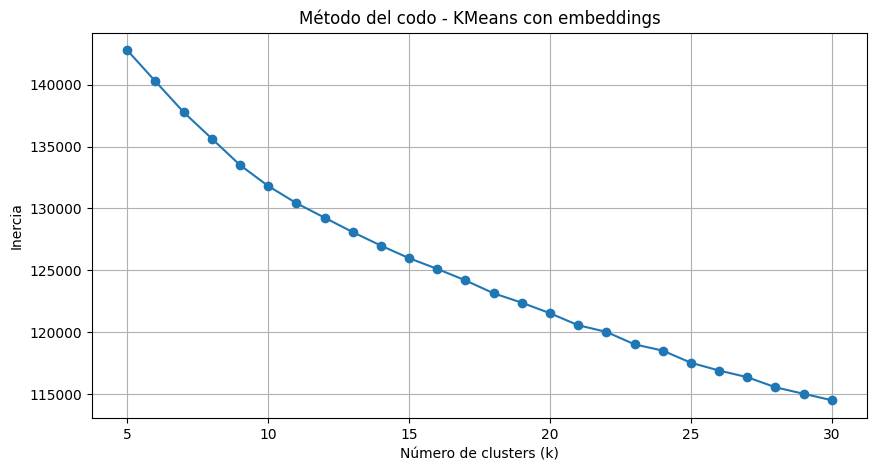

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(resultados_kmeans["k"], resultados_kmeans["inercia"], marker="o")
plt.title("Método del codo - KMeans con embeddings")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

In [8]:
resultados_kmeans.to_excel("resultados_kmeans_elbow.xlsx", index=False)

In [9]:
best_k = 15

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

df_clusters["cluster_kmeans"] = kmeans_final.fit_predict(embeddings)

print(df_clusters["cluster_kmeans"].value_counts().sort_index())

cluster_kmeans
0     2122
1     2330
2     1793
3     2270
4     2592
5     1404
6     1308
7     2176
8      356
9      340
10    2556
11     963
12     946
13     904
14    1458
Name: count, dtype: int64


In [10]:
for c in sorted(df_clusters["cluster_kmeans"].unique()):
    print(f"\n===== CLUSTER KMEANS {c} =====")
    
    muestra = df_clusters.loc[
        df_clusters["cluster_kmeans"] == c,
        ["resuelve", "resuelve_tokens"]
    ].head(5)

    for _, fila in muestra.iterrows():
        print("Texto:", fila["resuelve"])
        print("Tokens:", fila["resuelve_tokens"])
        print("-" * 100)


===== CLUSTER KMEANS 0 =====
Texto: modifica acuerdo superior 083 de 1996 estatuto profesoral sobre comisiones administrativas
Tokens: ['modifica', 'estatuto', 'profesoral', 'comisiones', 'administrativas']
----------------------------------------------------------------------------------------------------
Texto: sustituir el capítulo ii del título segundo del acuerdo superior 124 de 1997 estatuto básico de extensión de la universidad de antioquia 
Tokens: ['sustituir', 'capítulo', 'ii', 'título', 'segundo', 'estatuto', 'básico', 'extensión']
----------------------------------------------------------------------------------------------------
Texto: conceder comision de servicios a edison dario neira palacio decano facultad de comunicaciones para coordinar convenio de cooperacion con universidad bielefeld alemania
Tokens: ['conceder', 'comision', 'servicios', 'edison', 'neira', 'palacio', 'decano', 'comunicaciones', 'coordinar', 'convenio', 'cooperacion', 'bielefeld', 'alemania']
-----

In [11]:
df_clusters.to_pickle("documentos_clusterizados_kmeans.pkl")
df_clusters.to_excel("documentos_clusterizados_kmeans.xlsx", index=False)